# 02 — pKa_Basic: ablation & model comparison

Compares **3 different modeling approaches** tried for pKa_Basic in this project's
history against the published benchmark (Jia et al., J. Med. Chem. 2025) and against each
other, to show why the final chosen architecture was selected.

*Every number in this notebook is read from an existing result file already produced by this
project (see the `source` column) -- this notebook does not train any model. The `Classical`,
`MFMN_Attention`, `ChemBERTa`, `GraphMPNN`, `Evidential`, and intermediate `MFMN_DynGate`/
`MFMN_InteractAux` rows are historical experiment-log results; the row marked **FINAL** was
independently re-verified this session (a fresh rerun matched the historical number closely --
see `mfmn_benchmark_package/notebooks/` for that from-scratch, fully executed reproduction).*



In [1]:
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_colwidth", 120)
df = pd.read_csv("../data/all_models_comparison.csv")
sub = df[df.target == "pKa_Basic"].copy()
sub = sub.sort_values("R2", ascending=False, na_position="last")
sub[["model", "description", "protocol", "R2", "MAE", "RMSE", "GMFE", "within_2fold", "n", "note"]]

,model,description,protocol,R2,MAE,RMSE,GMFE,within_2fold,n,note
12,GraphMPNN (GNN) -- FINAL,From-scratch edge-gated message-passing GNN,official-test,0.9478,0.4162,0.6705,NaN,NaN,815.0,CHOSEN MODEL
9,Paper (Jia et al. 2025),Published benchmark,official-test,0.9100,0.6700,0.9800,NaN,NaN,815.0,NaN
10,Classical RF+SVM+XGB,"3-model consensus, merged descriptors",official-test,0.8824,0.6948,1.0068,NaN,NaN,815.0,NaN
11,MFMN_Attention (v2 final),Multi-head self-attention -- the v2 project's best for this target,CV,NaN,0.6880,NaN,NaN,NaN,NaN,NaN


### Why GraphMPNN (GNN) was chosen

Same mechanistic story as pKa_Acidic (a localized protonation site, not a whole-molecule
aggregate property), using the analogous basic-site detector (`basic_site.py`, 97.5%
coverage). The GNN again clears both the classical baseline and the v2 project's best
descriptor-based answer (MFMN_Attention) by a wide margin -- R²=0.948 vs. classical's 0.882 and
Attention's historical MAE=0.688 vs. the GNN's 0.416.

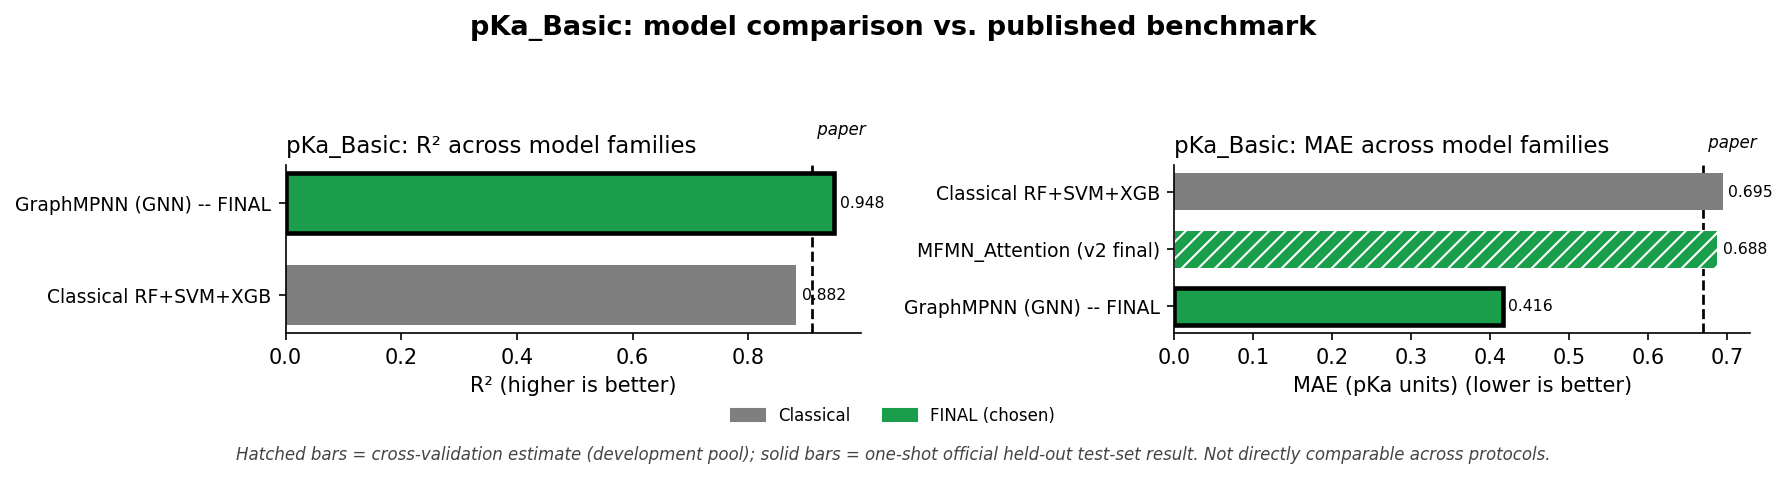

In [2]:
display(Image(filename="../figures/pKa_Basic_comparison.png"))

### Full comparison table (with sources)

The table below includes the `source` column pointing to the exact result file each number
came from, for independent verification.


In [3]:
sub[["model", "protocol", "R2", "MAE", "RMSE", "GMFE", "within_2fold", "source"]].reset_index(drop=True)

,model,protocol,R2,MAE,RMSE,GMFE,within_2fold,source
0,GraphMPNN (GNN) -- FINAL,official-test,0.9478,0.4162,0.6705,NaN,NaN,mfmn_benchmark_package/outputs/02_pKa_Basic_official_test_summary.csv (this session's fresh 10-seed rerun)
1,Paper (Jia et al. 2025),official-test,0.9100,0.6700,0.9800,NaN,NaN,PAPER dict (metrics.py)
2,Classical RF+SVM+XGB,official-test,0.8824,0.6948,1.0068,NaN,NaN,results/s2_aux_predictor_results.json
3,MFMN_Attention (v2 final),CV,NaN,0.6880,NaN,NaN,NaN,PROJECT_REPORT.md Section 4.6 (5-fold confirm)
